Saving table.txt to table (1).txt
Saving VCMA.txt to VCMA (1).txt


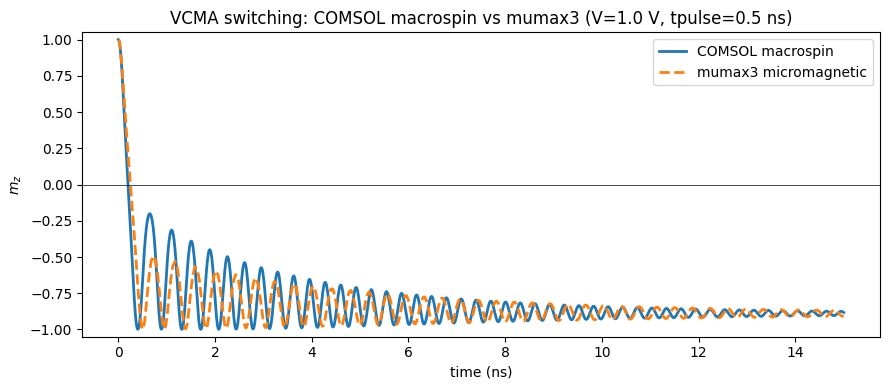

final mz   COMSOL = -0.883   mumax = -0.909
RMS(mz) over trace = 0.142


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from google.colab import files
files.upload()   # upload VCMA.txt (COMSOL) and table.txt (mumax)

# --- COMSOL: % comment lines, 2 columns (time, mz) ---
comsol = pd.read_csv("VCMA.txt", comment="%", sep=r"\s+",
                     header=None, names=["t", "mz"])

# --- mumax: one # header line; columns are t, mx, my, mz, E_total ---
mumax = pd.read_csv("table.txt", comment="#", sep=r"\s+", header=None,
                    names=["t", "mx", "my", "mz", "E"])

# --- overlay ---
plt.figure(figsize=(9, 4))
plt.plot(comsol.t*1e9, comsol.mz, "-",  lw=2, label="COMSOL macrospin")
plt.plot(mumax.t*1e9,  mumax.mz,  "--", lw=2, label="mumax3 micromagnetic")
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("time (ns)"); plt.ylabel(r"$m_z$"); plt.ylim(-1.05, 1.05)
plt.legend(); plt.title("VCMA switching: COMSOL macrospin vs mumax3 (V=1.0 V, tpulse=0.5 ns)")
plt.tight_layout(); plt.show()

# --- quantitative agreement ---
mz_mm = np.interp(comsol.t, mumax.t, mumax.mz)   # mumax onto COMSOL time grid
rms = np.sqrt(np.mean((comsol.mz - mz_mm)**2))
print(f"final mz   COMSOL = {comsol.mz.iloc[-1]:+.3f}   mumax = {mumax.mz.iloc[-1]:+.3f}")
print(f"RMS(mz) over trace = {rms:.3f}")

Saving SOT.txt to SOT (4).txt
Saving table.txt to table (4).txt
Reading COMSOL file: SOT (4).txt
Reading MuMax3 file: table (4).txt


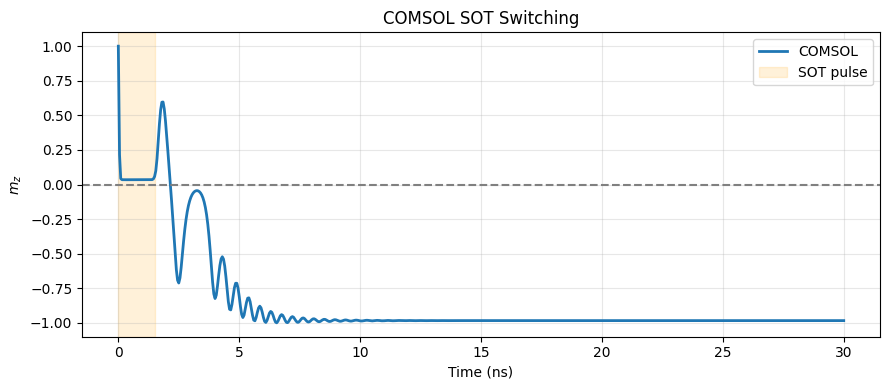

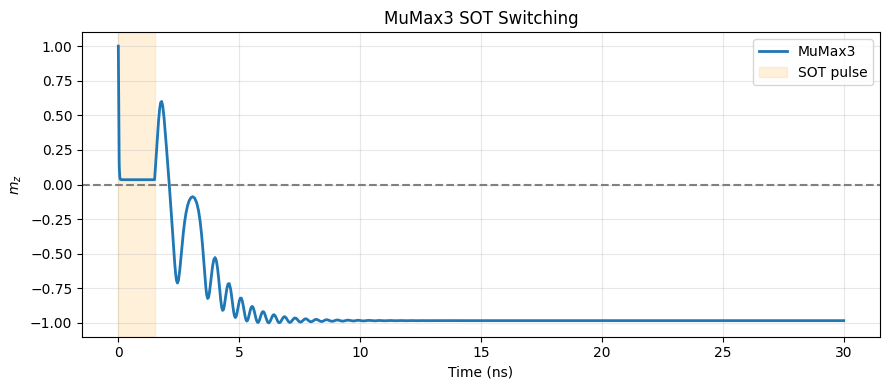

In [ ]:
from google.colab import files
import pandas as pd
import io
import matplotlib.pyplot as plt

# ==========================================
# Upload BOTH files
# ==========================================

uploaded = files.upload()

comsol_df = None
mumax_df = None

for fname, content in uploaded.items():

    raw = content.decode("utf-8")

    # ======================================
    # MuMax3 file
    # ======================================
    if raw.lstrip().startswith("#"):

        print(f"Reading MuMax3 file: {fname}")

        header = raw.splitlines()[0].lstrip("#").strip()
        cols = [c.strip() for c in header.split("\t")]

        df = pd.read_csv(
            io.StringIO(raw),
            sep="\t",
            comment="#",
            names=cols
        )

        df.columns = [c.split(" (")[0].strip() for c in df.columns]

        mumax_df = df

    # ======================================
    # COMSOL file
    # ======================================
    else:

        print(f"Reading COMSOL file: {fname}")

        data = "\n".join(
            line for line in raw.splitlines()
            if line.strip() and not line.startswith("%")
        )

        df = pd.read_csv(
            io.StringIO(data),
            sep=r"\s+",
            names=["t", "mz"],
            engine="python"
        )

        comsol_df = df


# ==========================================
# Plot COMSOL
# ==========================================

if comsol_df is not None:

    plt.figure(figsize=(9,4))

    plt.plot(
        comsol_df["t"]*1e9,
        comsol_df["mz"],
        lw=2,
        label="COMSOL"
    )

    plt.axvspan(0,1.5,color="orange",alpha=0.15,label="SOT pulse")
    plt.axhline(0,color="gray",ls="--")

    plt.xlabel("Time (ns)")
    plt.ylabel(r"$m_z$")
    plt.title("COMSOL SOT Switching")
    plt.ylim(-1.1,1.1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==========================================
# Plot MuMax3
# ==========================================

if mumax_df is not None:

    plt.figure(figsize=(9,4))

    plt.plot(
        mumax_df["t"]*1e9,
        mumax_df["mz"],
        lw=2,
        label="MuMax3"
    )

    plt.axvspan(0,1.5,color="orange",alpha=0.15,label="SOT pulse")
    plt.axhline(0,color="gray",ls="--")

    plt.xlabel("Time (ns)")
    plt.ylabel(r"$m_z$")
    plt.title("MuMax3 SOT Switching")
    plt.ylim(-1.1,1.1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()